# 01 — `master_daily` 데이터 탐색

SQLite `data/db/soybean.db`의 **`master_daily`** 테이블을 로드해 대두유(ZL) 중심으로 시계열·정상성·결측·상관·타깃·자기상관을 살펴봅니다.

**가정 행 수·기간(참고):** 약 1,824행, 55컬럼, 2019-01-02 ~ 2026-04-02

## 1. 환경 설정

프로젝트 루트에 `data/db/soybean.db`가 있으면 그 경로를 사용하고, 없으면 상위 디렉터리를 루트로 간주합니다. 노트북 환경에서 **작업 폴더가 `soybean-oil-poc` 또는 `notebooks`**인 경우 모두 동작하도록 했습니다.

**Python 커널:** **`soybean-oil-poc/.venv`** 인터프리터를 선택하는 것이 좋습니다. 다른 커널을 쓰면 아래 코드가 **그 커널**에 패키지를 설치합니다. Plotly는 **`vscode` 렌더러**를 쓰면 `nbformat` 없이 표시됩니다(설정 셀에서 자동 선택). 클래식 Jupyter만 `%pip install "nbformat>=4.2.0" plotly matplotlib seaborn` 등이 필요할 수 있습니다.

In [1]:
from pathlib import Path
import importlib.util
import re
import sqlite3
import subprocess
import sys

import pandas as pd
from IPython.display import display


def _ensure_package(pkg: str) -> None:
    """현재 Jupyter 커널 환경에 패키지가 없으면 pip로 설치."""
    if importlib.util.find_spec(pkg) is not None:
        return
    print(f"[설치] {pkg} 가 없어 현재 커널에 설치합니다…")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
    )


_ensure_package("plotly")
_ensure_package("matplotlib")
_ensure_package("seaborn")

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "data" / "db" / "soybean.db").exists() else _cwd.parent
_src = ROOT / "src"
if str(_src.resolve()) not in sys.path:
    sys.path.insert(0, str(_src.resolve()))

import matplotlib
from utils.plot_style import configure_matplotlib_korean

configure_matplotlib_korean()

import plotly.io as pio

# 노트북 환경에서 `vscode` 렌더러는 nbformat 없이 fig.show() 가능.
# 클래식 Jupyter 등에서는 `notebook_connected` + nbformat>=4.2.0.
if "vscode" in pio.renderers:
    pio.renderers.default = "vscode"
else:
    _mj, _mn = 0, 0
    try:
        import nbformat as _nbformat

        _mm = re.match(r"(\d+)\.(\d+)", _nbformat.__version__)
        if _mm:
            _mj, _mn = int(_mm.group(1)), int(_mm.group(2))
    except Exception:
        pass
    if not (_mj > 4 or (_mj == 4 and _mn >= 2)):
        print("[설치] nbformat>=4.2.0 (Plotly notebook_connected 표시용)…")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "nbformat>=4.2.0"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.STDOUT,
        )
    pio.renderers.default = "notebook_connected"

DB_PATH = ROOT / "data" / "db" / "soybean.db"

if not DB_PATH.is_file():
    raise FileNotFoundError(f"DB 없음: {DB_PATH.resolve()}")

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query("SELECT * FROM master_daily ORDER BY date", conn)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").set_index("date")

print("DB:", DB_PATH.resolve())
print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes)
display(df.head())

DB: /Users/jjjiny/working/predict_soybeanoil/soybean-oil-poc/data/db/soybean.db
shape: (1824, 55)

dtypes:
 price_close                  float64
price_lag_1                  float64
price_lag_3                  float64
price_lag_7                  float64
price_lag_14                 float64
price_lag_30                 float64
price_ma_7                   float64
price_ma_14                  float64
price_ma_30                  float64
price_to_ma7_ratio           float64
price_to_ma14_ratio          float64
price_to_ma30_ratio          float64
return_1d                    float64
return_3d                    float64
return_7d                    float64
return_14d                   float64
volatility_5d                float64
volatility_10d               float64
volatility_20d               float64
usd_brl_close                float64
is_interpolated                int64
usd_brl_lag_1                float64
usd_brl_return_7d            float64
usd_brl_volatility_14d       float64
wti_

,price_close,price_lag_1,price_lag_3,price_lag_7,price_lag_14,price_lag_30,price_ma_7,price_ma_14,price_ma_30,price_to_ma7_ratio,...,is_flowering_season,is_harvest_season,days_to_next_harvest,palm_soyoil_spread,basis,target_price_t1,target_price_t7,target_return_t7,target_updown_t7,feature_version
date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,27.90,NaN,NaN,NaN,NaN,NaN,27.900000,27.900000,27.900000,1.000000,...,1,0,58,-534.85,NaN,28.18,28.170000,0.009677,1.0,v1
2019-01-03,28.18,27.90,NaN,NaN,NaN,NaN,28.040000,28.040000,28.040000,1.004993,...,1,0,57,-509.32,NaN,28.41,28.110001,-0.002484,0.0,v1
2019-01-04,28.41,28.18,NaN,NaN,NaN,NaN,28.163333,28.163333,28.163333,1.008758,...,1,0,56,-490.09,NaN,28.26,28.240000,-0.005984,0.0,v1
2019-01-07,28.26,28.41,27.90,NaN,NaN,NaN,28.187500,28.187500,28.187500,1.002572,...,1,0,53,-445.74,NaN,28.18,28.230000,-0.001062,0.0,v1
2019-01-08,28.18,28.26,28.18,NaN,NaN,NaN,28.186000,28.186000,28.186000,0.999787,...,1,0,52,-470.07,NaN,28.32,28.770000,0.020937,1.0,v1


## 2. 대두유 가격 시계열 (`plotly`)

- **종가** `price_close`와 **7일·30일 이동평균**을 겹쳐 그립니다.
- 참고용 **수직선**: 러시아-우크라이나 전쟁 개시일(2022-02-24), 인도네시아 팜유 수출 제한(2022-04-01 근사) — 해석은 단순 타임라인 표시입니다.

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio

# Plotly 한글: 브라우저/노트북이 참조할 폰트 스택 (matplotlib rcParams와 별개)
_PLOTLY_KO_FONT = "AppleGothic, 'Apple SD Gothic Neo', 'Malgun Gothic', sans-serif"

# 설정 셀을 다시 실행하지 않은 경우에도 notebook_connected+nbformat 오류 방지
if "vscode" in pio.renderers:
    pio.renderers.default = "vscode"

# 종가 및 이동평균 (master_daily에 price_ma_7 등이 있으나 여기서는 동일 정의로 오버레이)
px = df["price_close"].astype(float)
ma7 = px.rolling(7, min_periods=1).mean()
ma30 = px.rolling(30, min_periods=1).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=px.index, y=px, name="price_close", mode="lines", line=dict(width=1)))
fig.add_trace(go.Scatter(x=ma7.index, y=ma7, name="MA7", mode="lines", line=dict(dash="dot")))
fig.add_trace(go.Scatter(x=ma30.index, y=ma30, name="MA30", mode="lines", line=dict(dash="dash")))

# 주요 이벤트 수직선 (날짜 축은 datetime)
이벤트 = [
    ("2022-02-24", "러-우 전쟁"),
    ("2022-04-01", "인니 수출금지(근사)"),
]
for d, label in 이벤트:
    fig.add_shape(
        type="line",
        x0=d,
        x1=d,
        y0=0,
        y1=1,
        xref="x",
        yref="paper",
        line=dict(color="gray", width=1, dash="dash"),
    )
    fig.add_annotation(
        x=d,
        y=1,
        xref="x",
        yref="paper",
        text=label,
        showarrow=False,
        yanchor="bottom",
        font=dict(size=11, color="gray", family=_PLOTLY_KO_FONT),
    )

fig.update_layout(
    title="대두유 선물 종가(ZL) 및 이동평균",
    xaxis_title="날짜",
    yaxis_title="가격",
    hovermode="x unified",
    height=480,
    font=dict(family=_PLOTLY_KO_FONT),
)
fig.show()

## 3. ADF 검정 (`statsmodels`)

**H0: 단위근 존재(비정상)** — p-value < 0.05이면 H0 기각 → 정상성 증거로 해석할 수 있습니다. 시계열 길이·레짐 변화에 따라 결과가 달라질 수 있습니다.

In [3]:
from statsmodels.tsa.stattools import adfuller


def adf_row(name: str, s: pd.Series) -> dict:
    x = pd.to_numeric(s, errors="coerce").dropna()
    if len(x) < 20:
        return {"series": name, "n": len(x), "ADF": None, "p_value": None, "stationary_05": None}
    stat, p, *_ = adfuller(x.values, autolag="AIC")
    return {
        "series": name,
        "n": len(x),
        "ADF": stat,
        "p_value": p,
        "stationary_05": p < 0.05,
    }


rows = [
    adf_row("price_close", df["price_close"]),
    adf_row("return_7d", df["return_7d"]),
    adf_row("price_to_ma7_ratio", df["price_to_ma7_ratio"]),
]
adf_tbl = pd.DataFrame(rows)
adf_tbl["해석(p<0.05=정상성 증거)"] = adf_tbl["stationary_05"].map({True: "정상성 유의", False: "비정상 유의", None: "—"})
display(adf_tbl)

,series,n,ADF,p_value,stationary_05,해석(p<0.05=정상성 증거)
0,price_close,1824,-1.475859,5.454182e-01,False,비정상 유의
1,return_7d,1817,-7.308672,1.281380e-10,True,정상성 유의
2,price_to_ma7_ratio,1824,-11.962079,4.080052e-22,True,정상성 유의


## 4. 피처 그룹별 결측 비율

그룹 내 **컬럼별 결측 비율의 평균**을 막대로 표시합니다(그룹 요약 지표).

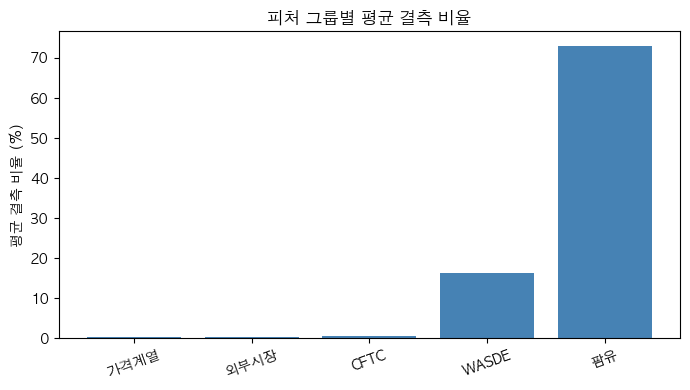

,group,mean_na_ratio,n_cols
0,가격계열,0.002597,19
1,외부시장,0.002657,13
2,CFTC,0.004751,3
3,WASDE,0.163377,3
4,팜유,0.730126,4


In [4]:
import matplotlib.pyplot as plt

# 타깃·버전 제외한 피처만
feat_cols = [c for c in df.columns if not c.startswith("target_") and c != "feature_version"]

groups = {
    "가격계열": [c for c in feat_cols if c.startswith("price_") or c.startswith("return_") or c.startswith("volatility_")],
    "외부시장": [c for c in feat_cols if c.startswith("usd_brl") or c.startswith("wti_") or c.startswith("crush_") or c in ("spot_price_usd", "basis")],
    "CFTC": [c for c in feat_cols if c.startswith("cftc_")],
    "WASDE": [c for c in feat_cols if c.startswith("wasde_")],
    "팜유": [c for c in feat_cols if c.startswith("palm_")],
}

summary = []
for gname, cols in groups.items():
    cols = [c for c in cols if c in df.columns]
    if not cols:
        summary.append({"group": gname, "mean_na_ratio": 0.0, "n_cols": 0})
        continue
    r = df[cols].isna().mean().mean()
    summary.append({"group": gname, "mean_na_ratio": r, "n_cols": len(cols)})

gdf = pd.DataFrame(summary)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(gdf["group"], gdf["mean_na_ratio"] * 100.0, color="steelblue")
ax.set_ylabel("평균 결측 비율 (%)")
ax.set_title("피처 그룹별 평균 결측 비율")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
display(gdf)

## 4a. v1 피처(팜유 4열 제외) 완전 행

`config/features.yaml`의 v1 `columns`에서 **`target_*`·`feature_version`을 뺀 피처**만 골라 `master_daily`와 맞춘 뒤, 그 열들이 **모두 비결측**인 행 수를 셉니다. v1 정의에서 `palm_close`, `palm_lag_1`, `palm_return_7d`, `palm_soyoil_spread`는 제외된 상태입니다.

**기대:** CFTC·WASDE 등이 충분히 채워진 DB면 **1700행 이상**. 초기 구간에 거시·포지션 결측이 길면 그보다 적을 수 있습니다.

In [5]:
import yaml

_cfg_path = ROOT / "config" / "features.yaml"
with open(_cfg_path, encoding="utf-8") as f:
    _cfg = yaml.safe_load(f)

_v1_cols: list[str] = _cfg["versions"]["v1"]["columns"]
v1_feat_cols = [
    c for c in _v1_cols
    if not str(c).startswith("target_") and c != "feature_version"
]
_missing = [c for c in v1_feat_cols if c not in df.columns]
if _missing:
    raise KeyError(f"master_daily에 없는 yaml v1 피처: {_missing}")

_sub = df[v1_feat_cols]
n_complete_v1 = int(_sub.notna().all(axis=1).sum())
print(f"v1 피처 전체 비결측 행: {n_complete_v1} / 전체 {len(df)}")
print("(yaml에서 팜유 4열 제외: palm_close, palm_lag_1, palm_return_7d, palm_soyoil_spread)")

_min_exp = 1700
if n_complete_v1 >= _min_exp:
    print(f"기대({_min_exp}행 이상) 충족.")
else:
    v1_no_cftc_wasde = [
        c for c in v1_feat_cols if not c.startswith("cftc_") and not c.startswith("wasde_")
    ]
    n_relaxed = int(df[v1_no_cftc_wasde].notna().all(axis=1).sum())
    print(
        f"현재 {n_complete_v1}행 (< {_min_exp}). CFTC·WASDE 초기 결측이 길면 흔합니다. "
        f"참고: CFTC·WASDE 열 제외 시 비결측 행 {n_relaxed}행."
    )


v1 피처 전체 비결측 행: 1526 / 전체 1824
(yaml에서 팜유 4열 제외: palm_close, palm_lag_1, palm_return_7d, palm_soyoil_spread)
현재 1526행 (< 1700). CFTC·WASDE 초기 결측이 길면 흔합니다. 참고: CFTC·WASDE 열 제외 시 비결측 행 1794행.


## 5. 주요 피처 상관관계 (`seaborn`)

선택 변수 간 Pearson 상관. 결측은 pairwise로 제외됩니다.

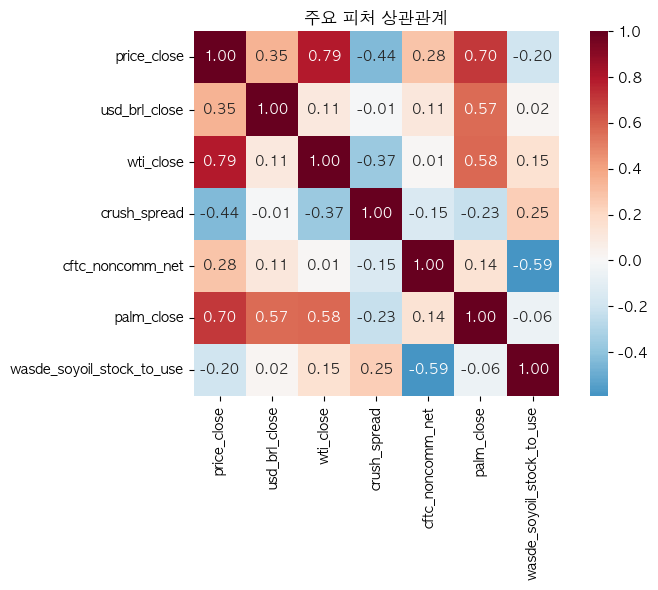

In [6]:
import seaborn as sns

corr_cols = [
    "price_close",
    "usd_brl_close",
    "wti_close",
    "crush_spread",
    "cftc_noncomm_net",
    "palm_close",
    "wasde_soyoil_stock_to_use",
]
corr_cols = [c for c in corr_cols if c in df.columns]
sub = df[corr_cols].apply(pd.to_numeric, errors="coerce")
cm = sub.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("주요 피처 상관관계")
plt.tight_layout()
plt.show()

## 6. 타깃 분포

- **`target_updown_t7`**: 7거래일 선행 수익률 부호(상승=1 / 하락=0), 결측 제외 후 파이.
- **`target_return_t7`**: 연속 수익률 히스토그램.

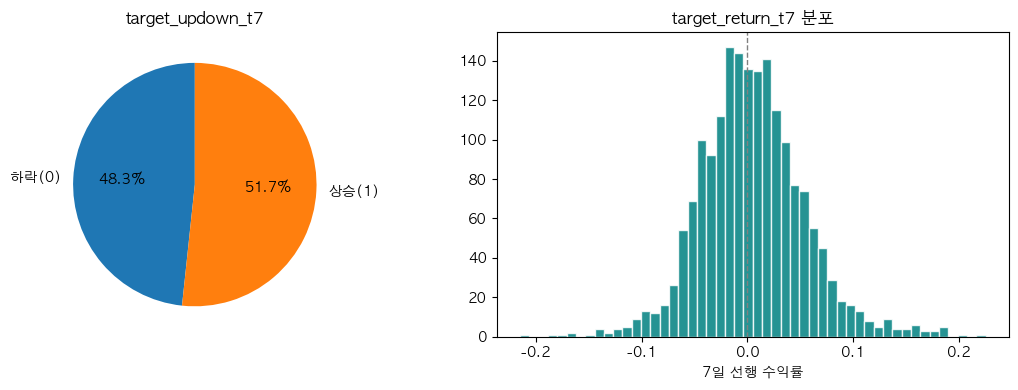

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ud = df["target_updown_t7"].dropna()
if len(ud) > 0:
    vc = ud.astype(int).value_counts().reindex([0, 1], fill_value=0)
    axes[0].pie(vc.values, labels=["하락(0)", "상승(1)"], autopct="%1.1f%%", startangle=90)
    axes[0].set_title("target_updown_t7")
else:
    axes[0].text(0.5, 0.5, "데이터 없음", ha="center")

tr = pd.to_numeric(df["target_return_t7"], errors="coerce").dropna()
axes[1].hist(tr, bins=50, color="teal", edgecolor="white", alpha=0.85)
axes[1].set_title("target_return_t7 분포")
axes[1].set_xlabel("7일 선행 수익률")
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

## 7. `price_close` Lag 자기상관 (ACF / PACF)

`statsmodels`의 `plot_acf` / `plot_pacf`로 시각화합니다. **신뢰구간 밖의 막대**를 대략적인 유의 lag 후보로 볼 수 있으나, 실제 검정은 별도 진단이 필요합니다.

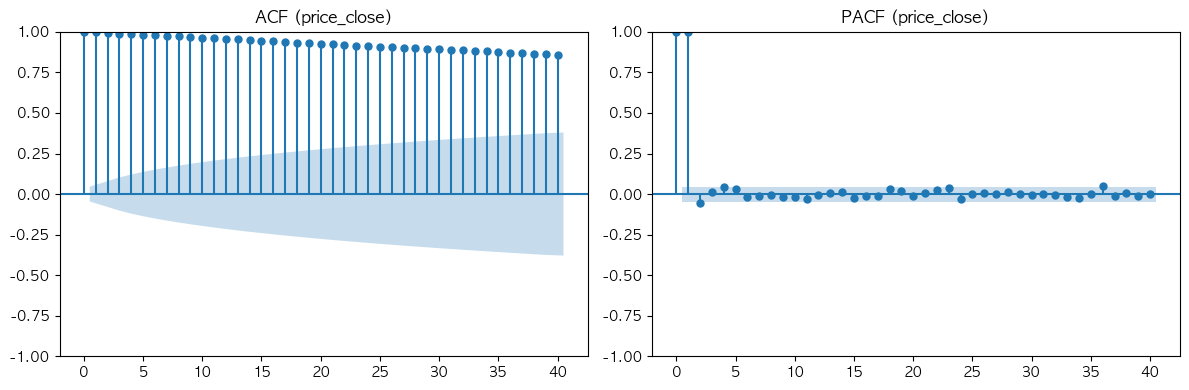

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = pd.to_numeric(df["price_close"], errors="coerce").dropna()
max_lags = min(40, len(y) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, ax=axes[0], lags=max_lags, title="ACF (price_close)")
plot_pacf(y, ax=axes[1], lags=max_lags, method="ywm", title="PACF (price_close)")
plt.tight_layout()
plt.show()

## 8. v1 피처 기준 완전 행(결측 없음) 개수

`config/features.yaml`의 **v1 `columns`**에서 타깃·`feature_version`을 제외한 피처만 사용합니다. (v1 목록에서 팜유 4열은 제외됨 — **4a**와 동일 정의.)

- **전체 v1 피처**가 모두 비결측인 행 수
- **CFTC 열 제외** 시 완전 행 수
- **WASDE 열 제외** 시 완전 행 수
- **CFTC·WASDE 둘 다 제외** 시 완전 행 수

In [ ]:
import yaml

cfg_path = ROOT / "config" / "features.yaml"
with open(cfg_path, encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

v1_all = cfg["versions"]["v1"]["columns"]
v1_features = [c for c in v1_all if not str(c).startswith("target_") and c != "feature_version"]
v1_features = [c for c in v1_features if c in df.columns]

cftc_f = [c for c in v1_features if c.startswith("cftc_")]
wasde_f = [c for c in v1_features if c.startswith("wasde_")]

def n_complete(cols: list[str]) -> int:
    if not cols:
        return len(df)
    return int(df[cols].notna().all(axis=1).sum())

rows = [
    {"case": "v1 피처 전체 (CFTC·WASDE 포함)", "n_complete": n_complete(v1_features)},
    {"case": "CFTC 열 제외", "n_complete": n_complete([c for c in v1_features if c not in cftc_f])},
    {"case": "WASDE 열 제외", "n_complete": n_complete([c for c in v1_features if c not in wasde_f])},
    {
        "case": "CFTC·WASDE 둘 다 제외",
        "n_complete": n_complete([c for c in v1_features if c not in cftc_f and c not in wasde_f]),
    },
]
comp_df = pd.DataFrame(rows)
comp_df["전체 대비 %"] = (100.0 * comp_df["n_complete"] / len(df)).round(2)
display(comp_df)
print("전체 행 수:", len(df))

,case,n_complete,전체 대비 %
0,v1 피처 전체 (CFTC·WASDE 포함),1526,83.66
1,CFTC 열 제외,1526,83.66
2,WASDE 열 제외,1794,98.36
3,CFTC·WASDE 둘 다 제외,1794,98.36


전체 행 수: 1824
